# Chapter 1: Naive Generator

In this section, we try a very simple idea:  
Give random noise to a model and ask it to directly produce an image.

We will see that this fails (blurry results), but it sets the stage for the next chapter where we add noise and then remove it (denoising).

In [9]:
import data
import torch
import utils
import models
from torch import nn, optim

## Define a simple generator model

This model starts from a small noise vector (shape: 256, 1, 1) and gradually upsamples it to a 32x32 RGB image.

We use bilinear upsampling + residual convolution blocks.

In [10]:
model = nn.Sequential(
    nn.Upsample(scale_factor=4, mode='bilinear'),
    models.ResConvBlock(256, 256, 128), 
    nn.Upsample(scale_factor=2, mode='bilinear'),
    models.ResConvBlock(128, 128, 64), 
    nn.Upsample(scale_factor=2, mode='bilinear'),
    models.ResConvBlock(64, 64, 32), 
    nn.Upsample(scale_factor=2, mode='bilinear'),
    models.ResConvBlock(32, 32, 3), 
)

## Dataset: Pair (Noise, Real Image)

Instead of loading normal images, we create a dataset that returns:

- **x**: random Gaussian noise (shape: 256, 1, 1)  
- **y**: a real CIFAR-10 image

The model will learn to map `x → y` using MSE loss.

In [ ]:
class NoiseToCIFAR10(data.Dataset):
    def __init__(self, shape, train=True, normalize=False):
        self.shape = shape
        self.cifar10 = data.get_cifar10(train=train, normalize=normalize)
    
    def __len__(self):
        return len(self.cifar10)
    
    def __getitem__(self, index):
        y, _ = self.cifar10[index]          # real image
        x = torch.randn(self.shape)         # random noise
        return x, y

dataloader = data.DataLoader(NoiseToCIFAR10((256, 1, 1)), batch_size=64, shuffle=True)
optimizer = optim.Adam(model.parameters(), 1e-3)
loss_fn = nn.MSELoss()

## Training loop (few steps)

We show an image before training, then train for 3 epochs and see results.

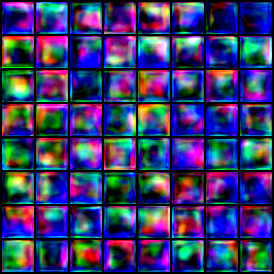

Loss: 0.0628101: 100%|██████████| 782/782 [05:53<00:00,  2.21it/s]


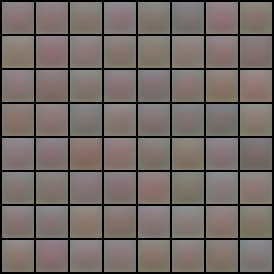

Loss: 0.0617068: 100%|██████████| 782/782 [05:49<00:00,  2.23it/s]


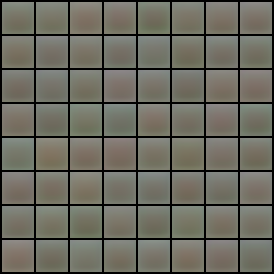

Loss: 0.0625892: 100%|██████████| 782/782 [05:42<00:00,  2.28it/s]


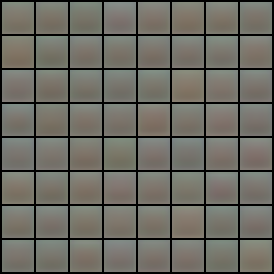

In [12]:
demo = model(next(iter(dataloader))[0])
utils.show_image(demo)
for i in range(3):
    utils.train(model, dataloader, optimizer, loss_fn)
    demo = model(next(iter(dataloader))[0])
    utils.show_image(demo)

## Observations (Important!)

As you can see, the generated images are **very blurry**.

**Why?**  
There is no structural relationship between the input noise (random) and the target image. The model cannot learn a meaningful one-to-one mapping.

**But look carefully** — even though they are blurry, you can sometimes see **faint shapes** or color patterns.  
This is not random. The model is trying to average all possible images that could come from noise. That "average" looks like a blurry mess.

> 💡 This blurriness will become the foundation of the next chapter:  
> We will **add noise to real images**, then train the model to **remove it** step by step (denoising). That works much better.

---

### What did we learn?

- Direct noise → image mapping fails.
- The model produces a **mean/average** of possible outputs → blur.
- Next step: denoising instead of direct generation (Diffusion Models).

$$
f(noise) \approx \frac{cat + car}{2}
$$